In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [ ]:
df=pd.read_csv("/content/swiggy.csv")
df

,id,name,city,rating,rating_count,cost,cuisine,lic_no,link,address,menu
0,567335,AB FOODS POINT,Abohar,--,Too Few Ratings,₹ 200,"Beverages,Pizzas",22122652000138,https://www.swiggy.com/restaurants/ab-foods-po...,"AB FOODS POINT, NEAR RISHI NARANG DENTAL CLINI...",Menu/567335.json
1,531342,Janta Sweet House,Abohar,4.4,50+ ratings,₹ 200,"Sweets,Bakery",12117201000112,https://www.swiggy.com/restaurants/janta-sweet...,"Janta Sweet House, Bazar No.9, Circullar Road,...",Menu/531342.json
2,158203,theka coffee desi,Abohar,3.8,100+ ratings,₹ 100,Beverages,22121652000190,https://www.swiggy.com/restaurants/theka-coffe...,"theka coffee desi, sahtiya sadan road city",Menu/158203.json
3,187912,Singh Hut,Abohar,3.7,20+ ratings,₹ 250,"Fast Food,Indian",22119652000167,https://www.swiggy.com/restaurants/singh-hut-n...,"Singh Hut, CIRCULAR ROAD NEAR NEHRU PARK ABOHAR",Menu/187912.json
4,543530,GRILL MASTERS,Abohar,--,Too Few Ratings,₹ 250,"Italian-American,Fast Food",12122201000053,https://www.swiggy.com/restaurants/grill-maste...,"GRILL MASTERS, ADA Heights, Abohar - Hanumanga...",Menu/543530.json
...,...,...,...,...,...,...,...,...,...,...,...
148536,553122,The Food Delight,Yavatmal,--,Too Few Ratings,₹ 200,"Fast Food,Snacks",21522053000452,https://www.swiggy.com/restaurants/the-food-de...,"The Food Delight, 94MC+X35, New Singhania Naga...",Menu/553122.json
148537,562647,MAITRI FOODS & BEVERAGES,Yavatmal,--,Too Few Ratings,₹ 300,Pizzas,license,https://www.swiggy.com/restaurants/maitri-food...,"MAITRI FOODS & BEVERAGES, POLIC MITRYA SOCIETY...",Menu/562647.json
148538,559435,Cafe Bella Ciao,Yavatmal,--,Too Few Ratings,₹ 300,"Fast Food,Snacks",21522251000378,https://www.swiggy.com/restaurants/cafe-bella-...,"Cafe Bella Ciao, SHOP NO 2 NEMANI MARKET SBI S...",Menu/559435.json
148539,418989,GRILL ZILLA,Yavatmal,--,Too Few Ratings,₹ 250,Continental,21521251000241,https://www.swiggy.com/restaurants/grill-zilla...,"GRILL ZILLA, SHO NO 2/6, POSTEL GROUND CHOWPAT...",Menu/418989.json


In [ ]:
#Examine data set

In [ ]:
df.shape


(148541, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148541 entries, 0 to 148540
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            148541 non-null  int64 
 1   name          148455 non-null  object
 2   city          148541 non-null  object
 3   rating        148455 non-null  object
 4   rating_count  148455 non-null  object
 5   cost          148410 non-null  object
 6   cuisine       148442 non-null  object
 7   lic_no        148312 non-null  object
 8   link          148541 non-null  object
 9   address       148455 non-null  object
 10  menu          148541 non-null  object
dtypes: int64(1), object(10)
memory usage: 12.5+ MB


In [ ]:
df.describe()

,id
count,148541.000000
mean,363466.378912
std,167890.977174
min,211.000000
25%,233320.000000
50%,412628.000000
75%,502223.000000
max,581031.000000


In [ ]:
# Drop rows with any missing values
df_cleaned = df.dropna()
df


,id,name,city,rating,rating_count,cost,cuisine,lic_no,link,address,menu
0,567335,AB FOODS POINT,Abohar,--,Too Few Ratings,₹ 200,"Beverages,Pizzas",22122652000138,https://www.swiggy.com/restaurants/ab-foods-po...,"AB FOODS POINT, NEAR RISHI NARANG DENTAL CLINI...",Menu/567335.json
1,531342,Janta Sweet House,Abohar,4.4,50+ ratings,₹ 200,"Sweets,Bakery",12117201000112,https://www.swiggy.com/restaurants/janta-sweet...,"Janta Sweet House, Bazar No.9, Circullar Road,...",Menu/531342.json
2,158203,theka coffee desi,Abohar,3.8,100+ ratings,₹ 100,Beverages,22121652000190,https://www.swiggy.com/restaurants/theka-coffe...,"theka coffee desi, sahtiya sadan road city",Menu/158203.json
3,187912,Singh Hut,Abohar,3.7,20+ ratings,₹ 250,"Fast Food,Indian",22119652000167,https://www.swiggy.com/restaurants/singh-hut-n...,"Singh Hut, CIRCULAR ROAD NEAR NEHRU PARK ABOHAR",Menu/187912.json
4,543530,GRILL MASTERS,Abohar,--,Too Few Ratings,₹ 250,"Italian-American,Fast Food",12122201000053,https://www.swiggy.com/restaurants/grill-maste...,"GRILL MASTERS, ADA Heights, Abohar - Hanumanga...",Menu/543530.json
...,...,...,...,...,...,...,...,...,...,...,...
148536,553122,The Food Delight,Yavatmal,--,Too Few Ratings,₹ 200,"Fast Food,Snacks",21522053000452,https://www.swiggy.com/restaurants/the-food-de...,"The Food Delight, 94MC+X35, New Singhania Naga...",Menu/553122.json
148537,562647,MAITRI FOODS & BEVERAGES,Yavatmal,--,Too Few Ratings,₹ 300,Pizzas,license,https://www.swiggy.com/restaurants/maitri-food...,"MAITRI FOODS & BEVERAGES, POLIC MITRYA SOCIETY...",Menu/562647.json
148538,559435,Cafe Bella Ciao,Yavatmal,--,Too Few Ratings,₹ 300,"Fast Food,Snacks",21522251000378,https://www.swiggy.com/restaurants/cafe-bella-...,"Cafe Bella Ciao, SHOP NO 2 NEMANI MARKET SBI S...",Menu/559435.json
148539,418989,GRILL ZILLA,Yavatmal,--,Too Few Ratings,₹ 250,Continental,21521251000241,https://www.swiggy.com/restaurants/grill-zilla...,"GRILL ZILLA, SHO NO 2/6, POSTEL GROUND CHOWPAT...",Menu/418989.json


In [ ]:
df.isnull().sum()

,0
id,0
name,86
city,0
rating,86
rating_count,86
cost,131
cuisine,99
lic_no,229
link,0
address,86


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#Rating count

In [ ]:
rating_count_map = {
    'Too Few Ratings': 0,
    '20+ ratings': 20,
    '50+ ratings': 50,
    '100+ ratings': 100,
    '500+ ratings': 500,
    '1K+ ratings': 1000,
    '5K+ ratings': 5000,
    '10K+ ratings': 10000
}


In [ ]:
df['rating_count_num'] = df['rating_count'].map(rating_count_map)


In [ ]:
df['rating_count_num'] = df['rating_count_num'].fillna(0)


In [ ]:
df['rating_count_num'].dtype


dtype('float64')

<Axes: ylabel='Frequency'>

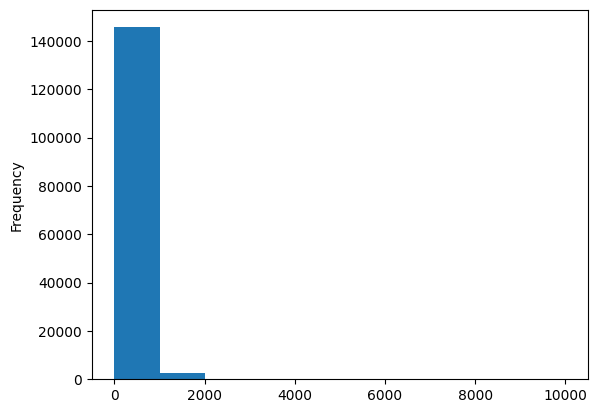

In [ ]:
df['rating_count_num'].plot(kind='hist', bins=10)


<Axes: xlabel='rating_count_num'>

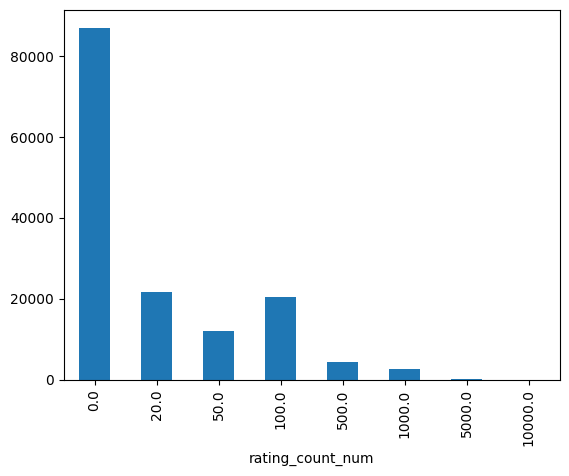

In [ ]:
df['rating_count_num'].value_counts().sort_index().plot(kind='bar')


In [ ]:
df['cost']=df['cost'].str.replace('₹', '', regex=False)
df['cost']=df['cost'].str.strip()

In [ ]:
## 1)Convert numeric columns

In [ ]:
# Convert numeric columns to numeric (fixes median error)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating_count'] = pd.to_numeric(df['rating_count'], errors='coerce')
df['cost'] = pd.to_numeric(df['cost'], errors='coerce')


In [ ]:
##2)Fill numeric columns with median

In [ ]:
df['rating'].fillna(df['rating'].median(), inplace=True)
df['rating_count'].fillna(df['rating_count'].median(), inplace=True)
df['cost'].fillna(df['cost'].median(), inplace=True)


/tmp/ipython-input-2292918733.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rating'].fillna(df['rating'].median(), inplace=True)
/tmp/ipython-input-2292918733.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [ ]:
##3) Fill categorical columns with mode

In [ ]:
df['name'].fillna(df['name'].mode().iloc[0], inplace=True)
df['cuisine'].fillna(df['cuisine'].mode().iloc[0], inplace=True)
df['lic_no'].fillna(df['lic_no'].mode().iloc[0], inplace=True)
df['address'].fillna(df['address'].mode().iloc[0], inplace=True)


/tmp/ipython-input-2225464575.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['name'].fillna(df['name'].mode().iloc[0], inplace=True)
/tmp/ipython-input-2225464575.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

<Axes: ylabel='Frequency'>

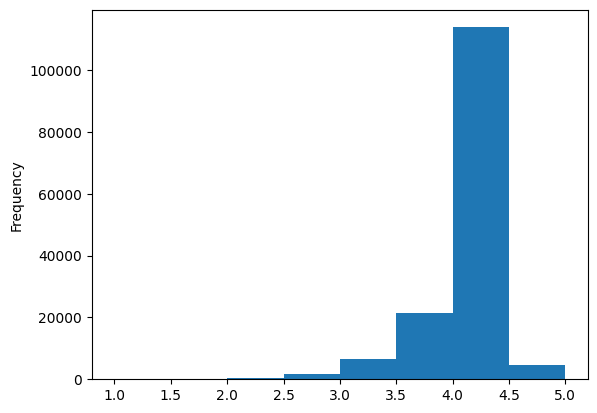

In [ ]:
df['rating'].plot(kind='hist', bins=8)


<Axes: xlabel='rating'>

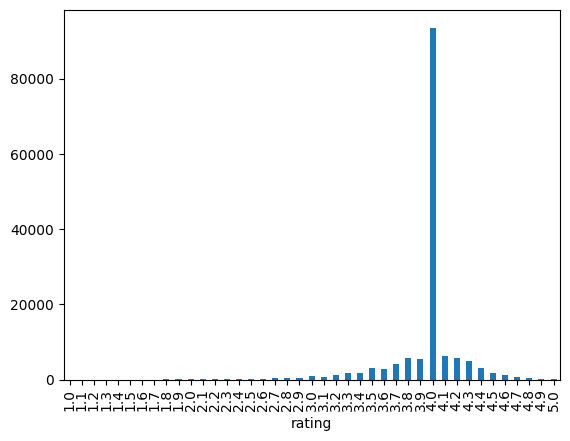

In [ ]:
df['rating'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='Frequency'>

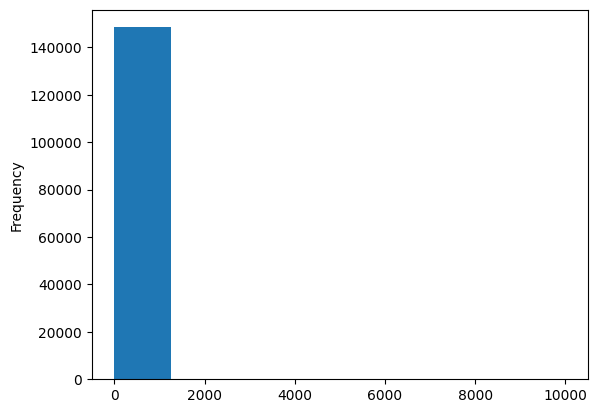

In [ ]:
df['rating_count_num'].plot(kind='hist', bins=8)


<Axes: xlabel='rating_count_num'>

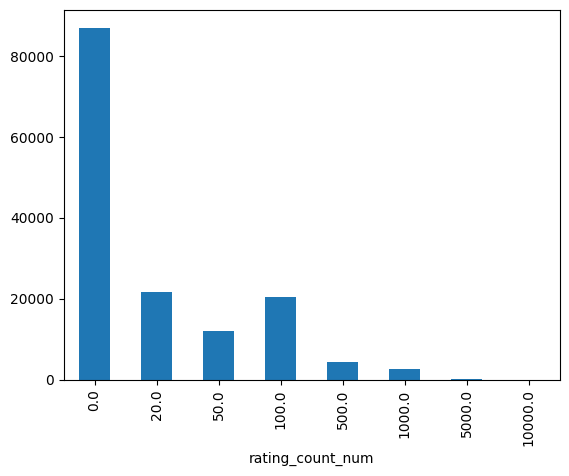

In [ ]:
df['rating_count_num'].value_counts().sort_index().plot(kind='bar')


In [ ]:
Q1 = df['cost'].quantile(0.25)
Q3 = df['cost'].quantile(0.75)
IQR = Q3 - Q1

upper_cap = Q3 + 1.5 * IQR

df['cost'] = df['cost'].clip(upper=upper_cap)

<Axes: ylabel='Frequency'>

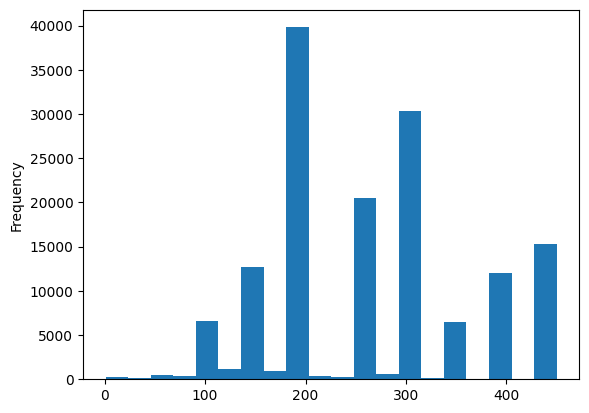

In [ ]:
df['cost'].plot(kind='hist', bins=20)

<Axes: >

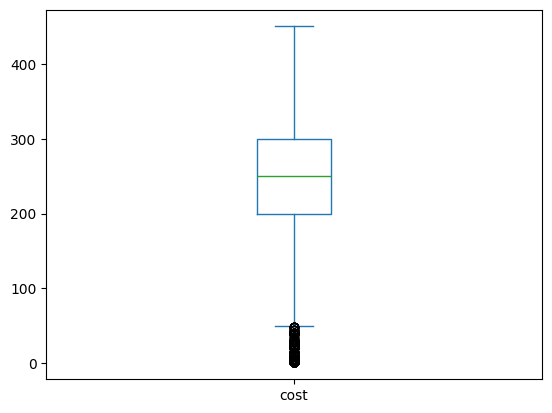

In [ ]:
df['cost'].plot(kind='box')

In [ ]:
df.isnull().sum()


,0
id,0
name,0
city,0
rating,0
rating_count,148541
cost,0
cuisine,0
lic_no,0
link,0
address,0


In [ ]:
df.drop(columns=['rating_count'], inplace = True)

In [ ]:
df

,id,name,city,rating,cost,cuisine,lic_no,link,address,menu,rating_count_num
0,567335,AB FOODS POINT,Abohar,4.0,200.0,"Beverages,Pizzas",22122652000138,https://www.swiggy.com/restaurants/ab-foods-po...,"AB FOODS POINT, NEAR RISHI NARANG DENTAL CLINI...",Menu/567335.json,0.0
1,531342,Janta Sweet House,Abohar,4.4,200.0,"Sweets,Bakery",12117201000112,https://www.swiggy.com/restaurants/janta-sweet...,"Janta Sweet House, Bazar No.9, Circullar Road,...",Menu/531342.json,50.0
2,158203,theka coffee desi,Abohar,3.8,100.0,Beverages,22121652000190,https://www.swiggy.com/restaurants/theka-coffe...,"theka coffee desi, sahtiya sadan road city",Menu/158203.json,100.0
3,187912,Singh Hut,Abohar,3.7,250.0,"Fast Food,Indian",22119652000167,https://www.swiggy.com/restaurants/singh-hut-n...,"Singh Hut, CIRCULAR ROAD NEAR NEHRU PARK ABOHAR",Menu/187912.json,20.0
4,543530,GRILL MASTERS,Abohar,4.0,250.0,"Italian-American,Fast Food",12122201000053,https://www.swiggy.com/restaurants/grill-maste...,"GRILL MASTERS, ADA Heights, Abohar - Hanumanga...",Menu/543530.json,0.0
...,...,...,...,...,...,...,...,...,...,...,...
148536,553122,The Food Delight,Yavatmal,4.0,200.0,"Fast Food,Snacks",21522053000452,https://www.swiggy.com/restaurants/the-food-de...,"The Food Delight, 94MC+X35, New Singhania Naga...",Menu/553122.json,0.0
148537,562647,MAITRI FOODS & BEVERAGES,Yavatmal,4.0,300.0,Pizzas,license,https://www.swiggy.com/restaurants/maitri-food...,"MAITRI FOODS & BEVERAGES, POLIC MITRYA SOCIETY...",Menu/562647.json,0.0
148538,559435,Cafe Bella Ciao,Yavatmal,4.0,300.0,"Fast Food,Snacks",21522251000378,https://www.swiggy.com/restaurants/cafe-bella-...,"Cafe Bella Ciao, SHOP NO 2 NEMANI MARKET SBI S...",Menu/559435.json,0.0
148539,418989,GRILL ZILLA,Yavatmal,4.0,250.0,Continental,21521251000241,https://www.swiggy.com/restaurants/grill-zilla...,"GRILL ZILLA, SHO NO 2/6, POSTEL GROUND CHOWPAT...",Menu/418989.json,0.0


<Axes: xlabel='city'>

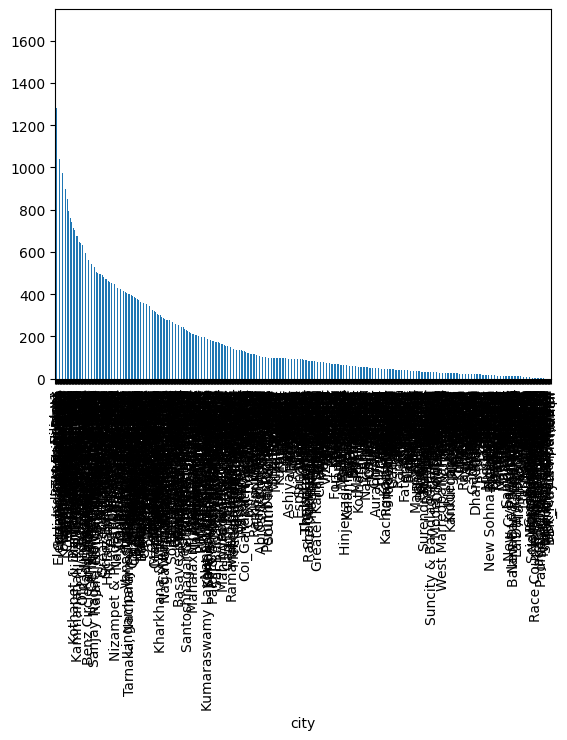

In [ ]:
df['city'].value_counts().plot(kind='bar')


<Axes: xlabel='cuisine'>

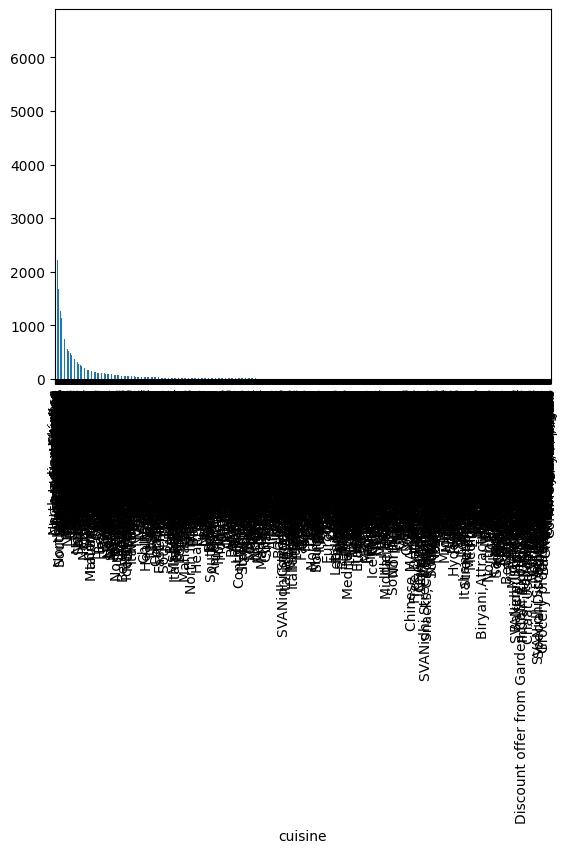

In [ ]:
df['cuisine'].value_counts().plot(kind='bar')


In [ ]:
df.isnull().sum()

,0
id,0
name,0
city,0
rating,0
cost,0
cuisine,0
lic_no,0
link,0
address,0
menu,0


In [ ]:
df

,id,name,city,rating,cost,cuisine,lic_no,link,address,menu,rating_count_num
0,567335,AB FOODS POINT,Abohar,4.0,200.0,"Beverages,Pizzas",22122652000138,https://www.swiggy.com/restaurants/ab-foods-po...,"AB FOODS POINT, NEAR RISHI NARANG DENTAL CLINI...",Menu/567335.json,0.0
1,531342,Janta Sweet House,Abohar,4.4,200.0,"Sweets,Bakery",12117201000112,https://www.swiggy.com/restaurants/janta-sweet...,"Janta Sweet House, Bazar No.9, Circullar Road,...",Menu/531342.json,50.0
2,158203,theka coffee desi,Abohar,3.8,100.0,Beverages,22121652000190,https://www.swiggy.com/restaurants/theka-coffe...,"theka coffee desi, sahtiya sadan road city",Menu/158203.json,100.0
3,187912,Singh Hut,Abohar,3.7,250.0,"Fast Food,Indian",22119652000167,https://www.swiggy.com/restaurants/singh-hut-n...,"Singh Hut, CIRCULAR ROAD NEAR NEHRU PARK ABOHAR",Menu/187912.json,20.0
4,543530,GRILL MASTERS,Abohar,4.0,250.0,"Italian-American,Fast Food",12122201000053,https://www.swiggy.com/restaurants/grill-maste...,"GRILL MASTERS, ADA Heights, Abohar - Hanumanga...",Menu/543530.json,0.0
...,...,...,...,...,...,...,...,...,...,...,...
148536,553122,The Food Delight,Yavatmal,4.0,200.0,"Fast Food,Snacks",21522053000452,https://www.swiggy.com/restaurants/the-food-de...,"The Food Delight, 94MC+X35, New Singhania Naga...",Menu/553122.json,0.0
148537,562647,MAITRI FOODS & BEVERAGES,Yavatmal,4.0,300.0,Pizzas,license,https://www.swiggy.com/restaurants/maitri-food...,"MAITRI FOODS & BEVERAGES, POLIC MITRYA SOCIETY...",Menu/562647.json,0.0
148538,559435,Cafe Bella Ciao,Yavatmal,4.0,300.0,"Fast Food,Snacks",21522251000378,https://www.swiggy.com/restaurants/cafe-bella-...,"Cafe Bella Ciao, SHOP NO 2 NEMANI MARKET SBI S...",Menu/559435.json,0.0
148539,418989,GRILL ZILLA,Yavatmal,4.0,250.0,Continental,21521251000241,https://www.swiggy.com/restaurants/grill-zilla...,"GRILL ZILLA, SHO NO 2/6, POSTEL GROUND CHOWPAT...",Menu/418989.json,0.0


In [ ]:
df[['cost', 'rating_count_num', 'rating']].skew()

,0
cost,0.362978
rating_count_num,17.243000
rating,-2.051882


In [ ]:
df['rating_count_log']=np.log1p(df['rating_count_num'])
df

,id,name,city,rating,cost,cuisine,lic_no,link,address,menu,rating_count_num,rating_count_log
0,567335,AB FOODS POINT,Abohar,4.0,200.0,"Beverages,Pizzas",22122652000138,https://www.swiggy.com/restaurants/ab-foods-po...,"AB FOODS POINT, NEAR RISHI NARANG DENTAL CLINI...",Menu/567335.json,0.0,0.000000
1,531342,Janta Sweet House,Abohar,4.4,200.0,"Sweets,Bakery",12117201000112,https://www.swiggy.com/restaurants/janta-sweet...,"Janta Sweet House, Bazar No.9, Circullar Road,...",Menu/531342.json,50.0,3.931826
2,158203,theka coffee desi,Abohar,3.8,100.0,Beverages,22121652000190,https://www.swiggy.com/restaurants/theka-coffe...,"theka coffee desi, sahtiya sadan road city",Menu/158203.json,100.0,4.615121
3,187912,Singh Hut,Abohar,3.7,250.0,"Fast Food,Indian",22119652000167,https://www.swiggy.com/restaurants/singh-hut-n...,"Singh Hut, CIRCULAR ROAD NEAR NEHRU PARK ABOHAR",Menu/187912.json,20.0,3.044522
4,543530,GRILL MASTERS,Abohar,4.0,250.0,"Italian-American,Fast Food",12122201000053,https://www.swiggy.com/restaurants/grill-maste...,"GRILL MASTERS, ADA Heights, Abohar - Hanumanga...",Menu/543530.json,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
148536,553122,The Food Delight,Yavatmal,4.0,200.0,"Fast Food,Snacks",21522053000452,https://www.swiggy.com/restaurants/the-food-de...,"The Food Delight, 94MC+X35, New Singhania Naga...",Menu/553122.json,0.0,0.000000
148537,562647,MAITRI FOODS & BEVERAGES,Yavatmal,4.0,300.0,Pizzas,license,https://www.swiggy.com/restaurants/maitri-food...,"MAITRI FOODS & BEVERAGES, POLIC MITRYA SOCIETY...",Menu/562647.json,0.0,0.000000
148538,559435,Cafe Bella Ciao,Yavatmal,4.0,300.0,"Fast Food,Snacks",21522251000378,https://www.swiggy.com/restaurants/cafe-bella-...,"Cafe Bella Ciao, SHOP NO 2 NEMANI MARKET SBI S...",Menu/559435.json,0.0,0.000000
148539,418989,GRILL ZILLA,Yavatmal,4.0,250.0,Continental,21521251000241,https://www.swiggy.com/restaurants/grill-zilla...,"GRILL ZILLA, SHO NO 2/6, POSTEL GROUND CHOWPAT...",Menu/418989.json,0.0,0.000000


In [ ]:
df[['cost', 'rating_count_num', 'rating']].skew()


,0
cost,0.362978
rating_count_num,17.243000
rating,-2.051882


In [ ]:
df[['cost', 'rating_count_log', 'rating']].skew()

,0
cost,0.362978
rating_count_log,0.705632
rating,-2.051882


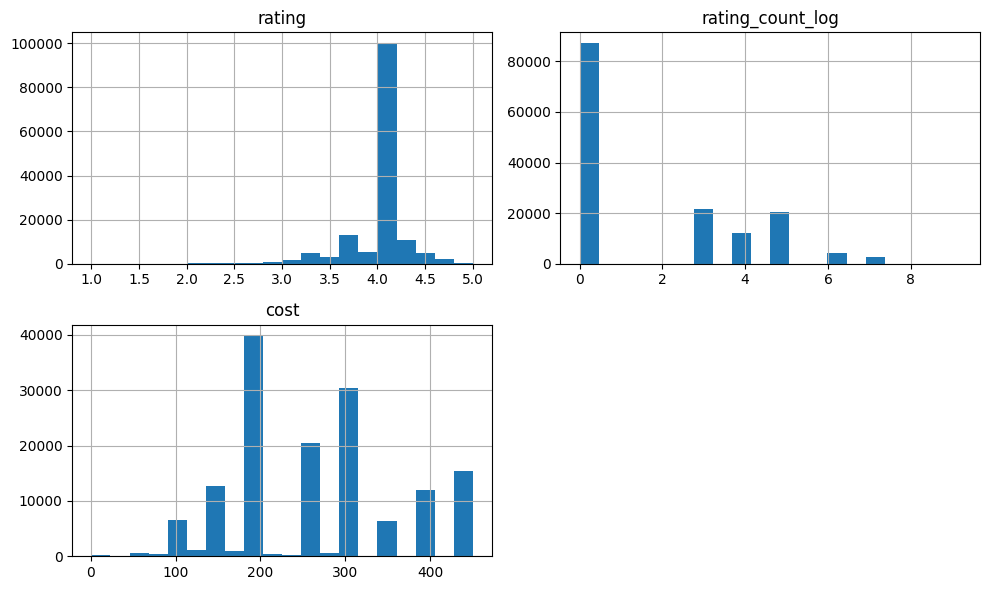

In [ ]:
df[['rating', 'rating_count_log', 'cost']].hist(bins=20, figsize=(10,6))
plt.tight_layout()
plt.show()

In [ ]:
df[['rating', 'rating_count_log', 'cost']].corr()


,rating,rating_count_log,cost
rating,1.000000,-0.094608,0.065854
rating_count_log,-0.094608,1.000000,0.086811
cost,0.065854,0.086811,1.000000


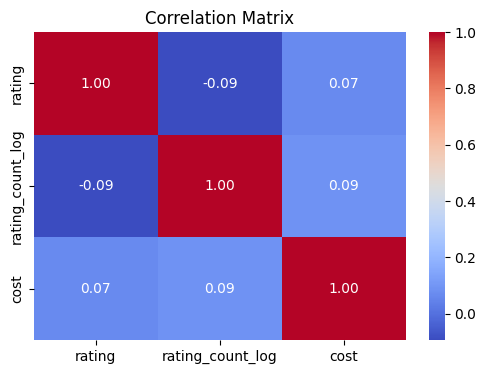

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(
    df[['rating', 'rating_count_log', 'cost']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
columns_to_drop = ['lic_no', 'link', 'menu', 'address']

df = df.drop(columns=columns_to_drop)


<Axes: xlabel='rating_count_log'>

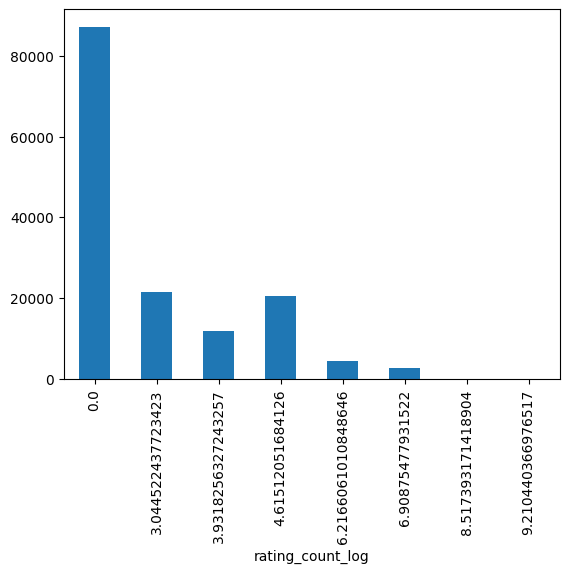

In [ ]:
df['rating_count_log'].value_counts().sort_index().plot(kind='bar')

In [ ]:
df.drop(columns=['rating_count_num'], inplace=True)


In [ ]:
df.columns


Index(['id', 'name', 'city', 'rating', 'cost', 'cuisine', 'rating_count_log'], dtype='object')

In [ ]:
df.to_csv("cleaned_data.csv", index=False)


In [ ]:
###ENCODING

In [ ]:
import pandas as pd
import pickle
from sklearn.preprocessing import MultiLabelBinarizer


In [ ]:
df = pd.read_csv("/content/cleaned_data.csv")
df


,id,name,city,rating,cost,cuisine,rating_count_log
0,567335,AB FOODS POINT,Abohar,4.0,200.0,"Beverages,Pizzas",0.000000
1,531342,Janta Sweet House,Abohar,4.4,200.0,"Sweets,Bakery",3.931826
2,158203,theka coffee desi,Abohar,3.8,100.0,Beverages,4.615121
3,187912,Singh Hut,Abohar,3.7,250.0,"Fast Food,Indian",3.044522
4,543530,GRILL MASTERS,Abohar,4.0,250.0,"Italian-American,Fast Food",0.000000
...,...,...,...,...,...,...,...
148536,553122,The Food Delight,Yavatmal,4.0,200.0,"Fast Food,Snacks",0.000000
148537,562647,MAITRI FOODS & BEVERAGES,Yavatmal,4.0,300.0,Pizzas,0.000000
148538,559435,Cafe Bella Ciao,Yavatmal,4.0,300.0,"Fast Food,Snacks",0.000000
148539,418989,GRILL ZILLA,Yavatmal,4.0,250.0,Continental,0.000000


In [ ]:
categorical_cols = ['city', 'cuisine']


In [3]:
cleaned_df = pd.read_csv('cleaned_data.csv')
print(cleaned_df.shape)

(148541, 7)


In [4]:
categorical_cols = ['city', 'cuisine']

In [5]:
TOP_CITIES = 50
TOP_CUISINES = 50


In [6]:
df = pd.read_csv("cleaned_data.csv")
df.columns = df.columns.str.strip().str.lower()


In [7]:
top_cities = df['city'].value_counts().head(TOP_CITIES).index

In [8]:
df['city_filtered'] = df['city'].apply(
    lambda x: x if x in top_cities else 'Other'
)


In [10]:
from collections import Counter

# Split cuisines
df['cuisine_list'] = df['cuisine'].apply(
    lambda x: [i.strip() for i in x.split(',')]
)

# Count cuisine frequency
all_cuisines = Counter(
    cuisine for sublist in df['cuisine_list'] for cuisine in sublist
)

top_cuisines = set(
    [c for c, _ in all_cuisines.most_common(TOP_CUISINES)]
)

# Keep only major cuisines
df['cuisine_filtered'] = df['cuisine_list'].apply(
    lambda x: [c for c in x if c in top_cuisines] or ['Other']
)


In [11]:
df['city_list'] = df['city_filtered'].apply(lambda x: [x])

In [12]:
from sklearn.preprocessing import MultiLabelBinarizer

city_mlb = MultiLabelBinarizer()
cuisine_mlb = MultiLabelBinarizer()

city_df = pd.DataFrame(
    city_mlb.fit_transform(df['city_list']),
    columns=city_mlb.classes_,
    index=df.index
)

cuisine_df = pd.DataFrame(
    cuisine_mlb.fit_transform(df['cuisine_filtered']),
    columns=cuisine_mlb.classes_,
    index=df.index
)


In [13]:
df_numeric = df[['rating', 'cost', 'rating_count_log']]

encoded_df = pd.concat([df_numeric, city_df, cuisine_df], axis=1)

In [14]:
print(encoded_df.shape)
print((encoded_df.index == df.index).all())


(148541, 105)
True


In [15]:
top_50_cities = df['city'].value_counts().head(50)
top_50_cities


city
Bikaner                                1666
Noida-1                                1428
Indirapuram,Delhi                      1279
BTM,Bangalore                          1161
Rohini,Delhi                           1136
Kothrud,Pune                           1089
Indiranagar,Bangalore                  1080
Electronic City,Bangalore              1039
Greater Kailash 2,Delhi                1038
Vashi,Mumbai                           1022
Kukatpally,Hyderabad                   1009
Viman Nagar,Pune                       1001
sohna road,Gurgaon                      976
Koramangala,Bangalore                   954
Laxmi Nagar,Delhi                       933
Gomti Nagar,Lucknow                     921
Malviya Nagar,Delhi                     901
HSR,Bangalore                           898
Madhapur,Hyderabad                      893
Wakad,Pune                              869
Raj Nagar,Noida                         852
Baner,Pune                              814
Bandra West,Mumbai         

In [16]:
top_50_cities.index.tolist()


['Bikaner',
 'Noida-1',
 'Indirapuram,Delhi',
 'BTM,Bangalore',
 'Rohini,Delhi',
 'Kothrud,Pune',
 'Indiranagar,Bangalore',
 'Electronic City,Bangalore',
 'Greater Kailash 2,Delhi',
 'Vashi,Mumbai',
 'Kukatpally,Hyderabad',
 'Viman Nagar,Pune',
 'sohna road,Gurgaon',
 'Koramangala,Bangalore',
 'Laxmi Nagar,Delhi',
 'Gomti Nagar,Lucknow',
 'Malviya Nagar,Delhi',
 'HSR,Bangalore',
 'Madhapur,Hyderabad',
 'Wakad,Pune',
 'Raj Nagar,Noida',
 'Baner,Pune',
 'Bandra West,Mumbai',
 'Central Kolkata,Kolkata',
 'Aliganj,Lucknow',
 'Powai,Mumbai',
 'Jadavpur,Kolkata',
 'Patna',
 'Whitefield,Bangalore',
 'Dwarka,Delhi',
 'Magarpatta,Pune',
 'Rajouri Garden,Delhi',
 'Banjara Hills,Hyderabad',
 'Kothapet & Dilsukhnagar,Hyderabad',
 'GTB Nagar,Delhi',
 'Dilshad Gardens,Delhi',
 'Arekere,Bangalore',
 'Kammanahalli/Kalyan Nagar,Bangalore',
 'Mayur Vihar,Delhi',
 'Bibwewadi,Pune',
 'Varanasi',
 'South Chd,Chandigarh',
 'Salt Lake,Kolkata',
 'Chattarpur,Delhi',
 'Faridabad',
 'Kanpur',
 'Chinar Park,Kolk

In [17]:
from collections import Counter

# Split cuisines into lists
cuisine_list = df['cuisine'].apply(
    lambda x: [i.strip() for i in x.split(',')]
)

# Count all cuisines
cuisine_counter = Counter(
    c for sublist in cuisine_list for c in sublist
)

# Top 50 cuisines
top_50_cuisines = cuisine_counter.most_common(50)

top_50_cuisines


[('Chinese', 36563),
 ('North Indian', 32636),
 ('Indian', 25716),
 ('Snacks', 17231),
 ('Biryani', 14523),
 ('Beverages', 14270),
 ('Fast Food', 13892),
 ('South Indian', 12014),
 ('Desserts', 11193),
 ('Pizzas', 9845),
 ('Bakery', 8838),
 ('Italian', 5369),
 ('Ice Cream', 5337),
 ('Continental', 3962),
 ('American', 3810),
 ('Sweets', 3036),
 ('Mughlai', 2753),
 ('Arabian', 2464),
 ('Tandoor', 2347),
 ('Street Food', 1993),
 ('Punjabi', 1916),
 ('Thalis', 1839),
 ('Juices', 1785),
 ('Chaat', 1753),
 ('Healthy Food', 1676),
 ('Asian', 1256),
 ('Kebabs', 1251),
 ('Pastas', 1199),
 ('Salads', 1081),
 ('Combo', 1021),
 ('Bengali', 940),
 ('Burgers', 911),
 ('Seafood', 894),
 ('Maharashtrian', 792),
 ('Lebanese', 721),
 ('Mexican', 662),
 ('Thai', 651),
 ('Italian-American', 630),
 ('Barbecue', 620),
 ('Andhra', 612),
 ('Tibetan', 590),
 ('Hyderabadi', 552),
 ('Kerala', 473),
 ('Gujarati', 383),
 ('Pan-Asian', 382),
 ('Home Food', 371),
 ('Cafe', 314),
 ('Grill', 309),
 ('Waffle', 284),
 

In [21]:
import pickle

# Create a dictionary with both encoders
encoder_dict = {
    'city_encoder': city_mlb,
    'cuisine_encoder': cuisine_mlb
}

# Save dictionary to a single Pickle file
with open('encoder.pkl', 'wb') as f:
    pickle.dump(encoder_dict, f)

print("Both encoders saved in 'encoder.pkl'")

Both encoders saved in 'encoder.pkl'


In [29]:
import pandas as pd
import pickle
from sklearn.preprocessing import MultiLabelBinarizer

df = pd.read_csv("cleaned_data.csv")

# Clean column names (important)
df.columns = df.columns.str.strip().str.lower()

# Ensure city is list-type
df["city"] = df["city"].astype(str)

# Ensure cuisine is list-type
df["cuisine"] = df["cuisine"].astype(str).apply(
    lambda x: [c.strip() for c in x.split(",")]
)
city_mlb = MultiLabelBinarizer()
cuisine_mlb = MultiLabelBinarizer()

city_encoded = city_mlb.fit_transform(df[["city"]].values)
cuisine_encoded = cuisine_mlb.fit_transform(df["cuisine"])

city_df = pd.DataFrame(
    city_encoded,
    columns=[f"city_{c}" for c in city_mlb.classes_]
)

cuisine_df = pd.DataFrame(
    cuisine_encoded,
    columns=[f"cuisine_{c}" for c in cuisine_mlb.classes_]
)

encoded_df = pd.concat([city_df, cuisine_df], axis=1)

encoded_df.to_csv("encoded_datanew.csv", index=False)
print("encoded_datanew1.csv saved")




encoded_datanew1.csv saved


In [30]:
encoder_dict = {
    "city_encoder": city_mlb,
    "cuisine_encoder": cuisine_mlb
}

with open("encoder.pkl", "wb") as f:
    pickle.dump(encoder_dict, f)

print("encoder.pkl saved")


encoder.pkl saved


In [32]:
print(encoded_df.shape)
print(len(city_mlb.classes_) + len(cuisine_mlb.classes_))


(148541, 947)
947


In [33]:
encoded_df.to_csv("encoded_datanew.csv", index=False)


In [34]:
encoded_df.to_csv("encoded_datanew.csv", index=False)
print("encoded_datanew.csv saved")


encoded_datanew.csv saved


In [ ]:
##PCA

In [35]:
encoded_df = pd.read_csv("encoded_datanew.csv")


In [36]:
encoded_df.isna().sum().sum()


np.int64(0)

In [37]:
encoded_df = encoded_df.fillna(0)


In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(encoded_df)


In [39]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42)
pca_data = pca.fit_transform(scaled_data)


In [40]:
print("Original shape:", encoded_df.shape)
print("After PCA shape:", pca_data.shape)
print("Explained variance:", pca.explained_variance_ratio_.sum())


Original shape: (148541, 947)
After PCA shape: (148541, 888)
Explained variance: 0.9505113615742325


In [41]:
pca_df = pd.DataFrame(
    pca_data,
    index=encoded_df.index
)


In [ ]:
print((pca_df.index == encoded_df.index).all())


True


In [ ]:
pca_df.to_csv("pca_data.csv", index=False)

In [30]:
encoded_df.head()


,rating,cost,rating_count_log,"Aliganj,Lucknow","Arekere,Bangalore","BTM,Bangalore","Bandra West,Mumbai","Baner,Pune","Banjara Hills,Hyderabad","Bibwewadi,Pune",...,Seafood,Snacks,South Indian,Street Food,Sweets,Tandoor,Thai,Thalis,Tibetan,Waffle
0,4.0,200.0,0.000000,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,4.4,200.0,3.931826,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,3.8,100.0,4.615121,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3.7,250.0,3.044522,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4.0,250.0,0.000000,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
################# COSINE SIMILIARITY

In [2]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity


In [3]:
encoded_df = pd.read_csv("encoded_datanew.csv")


In [4]:
def get_similar_restaurants(index, encoded_df, top_n=10):
    sim = cosine_similarity(
        encoded_df.iloc[index:index+1],
        encoded_df
    ).flatten()

    similar_indices = sim.argsort()[-top_n-1:-1][::-1]
    return similar_indices


In [5]:
similar_idx = get_similar_restaurants(100, encoded_df, top_n=10)
similar_idx


array([231, 410, 405, 181, 370, 131, 341, 331, 100, 436])

In [6]:
cleaned_df = pd.read_csv("cleaned_data.csv")

cleaned_df.iloc[similar_idx][["name", "city", "cuisine"]]


,name,city,cuisine
231,SURESH SOUTH INDIAN KITCHEN,Adityapur,South Indian
410,Balaji Tiffin ( Sunshine Enterprises),Adityapur,South Indian
405,The South Indian Dish,Adityapur,South Indian
181,Dosa king,Adityapur,South Indian
370,LALAJI KA DOSA CAFE & CUISINE,Adityapur,South Indian
131,The Madrasi Hotel,Adityapur,South Indian
341,DOSA JUNCTION,Adityapur,South Indian
331,Dosa Cafe (Hotel Ganga Regency),Adityapur,South Indian
100,NEW GANGOUR SWEETS (Adityapur),Adityapur,South Indian
436,Annapurna New Suruchi Hotel,Adityapur,"Indian,South Indian"


In [ ]:
##Mapping

In [7]:
(cleaned_df.index == encoded_df.index).all()


np.True_

In [8]:
cleaned_df = pd.read_csv("cleaned_data.csv")
encoded_df = pd.read_csv("encoded_datanew.csv")


In [9]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Choose a restaurant index (example)
query_index = 40823

similarity = cosine_similarity(
    encoded_df.iloc[[query_index]],
    encoded_df
).flatten()


In [10]:
top_n = 50

similar_idx = np.argsort(similarity)[-top_n-1:-1][::-1]


In [11]:
recommendations = cleaned_df.iloc[similar_idx][
    ["name", "city", "cuisine"]
]

recommendations


,name,city,cuisine
40843,Kerala Kitchen,"Arumbakkam,Chennai",South Indian
40858,The Circle Company,"Arumbakkam,Chennai",South Indian
40881,FRIENDS MILLET KITCHENS,"Arumbakkam,Chennai",South Indian
40837,PUTTU MACHI,"Arumbakkam,Chennai",South Indian
40832,DaDu ByTz (Unit of ZAS INTERNATIONL),"Arumbakkam,Chennai",South Indian
40823,Madurai Sathya Vilas,"Arumbakkam,Chennai",South Indian
40819,Bharani Bhavan,"Arumbakkam,Chennai",South Indian
40808,Kerala Spices,"Arumbakkam,Chennai",South Indian
40759,RAJALAKSHMI HOME COOKING,"Arumbakkam,Chennai",South Indian
40886,A2B VEG,"Arumbakkam,Chennai","South Indian,North Indian"


In [ ]:
##STREAMLIT

In [12]:
pip install streamlit scikit-learn pandas numpy


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
import pickle

with open("encoder.pkl", "rb") as f:
    encoders = pickle.load(f)

print(type(encoders))  # Is it dict or just a single object?
print(encoders)        # See what keys or objects are inside


<class 'dict'>
{'city_encoder': MultiLabelBinarizer(), 'cuisine_encoder': MultiLabelBinarizer()}


In [55]:
with open("encoder.pkl", "rb") as f:
    encoders = pickle.load(f)


In [56]:
import pickle
import pandas as pd

cleaned_df = pd.read_csv("cleaned_data.csv")
encoded_df = pd.read_csv("encoded_datanew.csv")

with open("encoder.pkl", "rb") as f:
    encoders = pickle.load(f)

print(type(encoders))
print(encoders)

city_encoder = encoders['city_encoder']
cuisine_encoder = encoders['cuisine_encoder']


<class 'dict'>
{'city_encoder': MultiLabelBinarizer(), 'cuisine_encoder': MultiLabelBinarizer()}


In [13]:
print(encoded_df.shape)


(148541, 947)


In [17]:
import pandas as pd
import pickle
import numpy as np

# Load encoded CSV
encoded_df = pd.read_csv("encoded_datanew.csv")

# Load encoders
with open("encoder.pkl", "rb") as f:
    encoders = pickle.load(f)

city_encoder = encoders["city_encoder"]
cuisine_encoder = encoders["cuisine_encoder"]

print("Encoded DF shape:", encoded_df.shape)
print("City encoder classes:", len(city_encoder.classes_))
print("Cuisine encoder classes:", len(cuisine_encoder.classes_))


Encoded DF shape: (148541, 947)
City encoder classes: 821
Cuisine encoder classes: 126


In [18]:
total_encoder_features = len(city_encoder.classes_) + len(cuisine_encoder.classes_)
print("Total encoder features:", total_encoder_features)

# Check if matches encoded_df columns
if total_encoder_features == encoded_df.shape[1]:
    print("✅ Encoder features match encoded data columns!")
else:
    print("❌ Mismatch! Check encoding steps.")


Total encoder features: 947
✅ Encoder features match encoded data columns!


In [19]:
# City columns
city_cols = [f"city_{c}" for c in city_encoder.classes_]
# Cuisine columns
cuisine_cols = [f"cuisine_{c}" for c in cuisine_encoder.classes_]

# Check encoded_df columns
encoded_cols = list(encoded_df.columns)

if all(col in encoded_cols for col in city_cols+cuisine_cols):
    print("✅ Column names match encoder classes!")
else:
    print("❌ Column names do not match encoder classes!")


✅ Column names match encoder classes!


In [20]:
# Pick a test city and cuisine
test_city = "Mumbai"
test_cuisine = ["Chinese", "Italian"]

# Build user vector
user_vector = np.zeros(encoded_df.shape[1])

# Activate city
if f"city_{test_city}" in encoded_df.columns:
    idx = encoded_df.columns.get_loc(f"city_{test_city}")
    user_vector[idx] = 1

# Activate cuisines
for c in test_cuisine:
    if f"cuisine_{c}" in encoded_df.columns:
        idx = encoded_df.columns.get_loc(f"cuisine_{c}")
        user_vector[idx] = 1

# Check shape
print("User vector shape:", user_vector.shape)
print("Encoded DF shape:", encoded_df.shape)

# Cosine similarity test
from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity([user_vector], encoded_df)
print("Similarity computed successfully! Shape:", similarity.shape)


User vector shape: (947,)
Encoded DF shape: (148541, 947)
Similarity computed successfully! Shape: (1, 148541)


In [21]:
print(user_vector.shape)
print(encoded_df.shape)


(947,)
(148541, 947)
